<a href="https://colab.research.google.com/github/himanshubhimte69/Parameter_Efficient_Deep_Learning-Class_Selective_Knowledge_Distillation_for_Precision_Agriculture/blob/main/Temperature.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!unzip Plant_Pathology_2020.zip

Archive:  Plant_Pathology_2020.zip
replace Plant Pathology 2020/Images/healthy/Train_100.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: Plant Pathology 2020/Images/healthy/Train_100.jpg  
  inflating: Plant Pathology 2020/Images/healthy/Train_1001.jpg  
  inflating: Plant Pathology 2020/Images/healthy/Train_1002.jpg  
  inflating: Plant Pathology 2020/Images/healthy/Train_1004.jpg  
  inflating: Plant Pathology 2020/Images/healthy/Train_1005.jpg  
  inflating: Plant Pathology 2020/Images/healthy/Train_1007.jpg  
  inflating: Plant Pathology 2020/Images/healthy/Train_1012.jpg  
  inflating: Plant Pathology 2020/Images/healthy/Train_1014.jpg  
  inflating: Plant Pathology 2020/Images/healthy/Train_1017.jpg  
  inflating: Plant Pathology 2020/Images/healthy/Train_1020.jpg  
  inflating: Plant Pathology 2020/Images/healthy/Train_103.jpg  
  inflating: Plant Pathology 2020/Images/healthy/Train_1031.jpg  
  inflating: Plant Pathology 2020/Images/healthy/Train_1034.jpg  
  inflatin

In [ ]:
# ============================================================
# 1. IMPORTS
# ============================================================

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score

from tensorflow.keras.applications import EfficientNetB4
from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    Dense
)

print("TensorFlow:", tf.__version__)


TensorFlow: 2.20.0


In [ ]:
# ============================================================
# 2. SETTINGS
# ============================================================

IMG_SIZE = (380,380)

BATCH_SIZE = 8

EPOCHS = 2

ALPHA = 0.7

temperature_values = [
    1,
    2,
    5,
    10,
    20
]

class_names = [
    "healthy",
    "rust",
    "scab"
]


In [ ]:
# ============================================================
# 3. LOAD DATASET
# ============================================================

train_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/Plant Pathology 2020/Images",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    validation_split=0.2,
    subset="training",
    seed=42
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/Plant Pathology 2020/Images",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    validation_split=0.2,
    subset="validation",
    seed=42
)

print("Dataset loaded")

Found 1730 files belonging to 3 classes.
Using 1384 files for training.
Found 1730 files belonging to 3 classes.
Using 346 files for validation.
Dataset loaded


In [ ]:
# ============================================================
# 4. BUILD TEACHER MODEL
# ============================================================

teacher_base = EfficientNetB4(
    include_top=False,
    weights=None,
    input_shape=(380,380,3)
)

teacher_model = tf.keras.Sequential([
    teacher_base,
    GlobalAveragePooling2D(),
    Dense(
        3,
        activation=None
    )
])

teacher_model.build(
    (None,380,380,3)
)

# ============================================================
# LOAD STABLE MODEL
# ============================================================

teacher_model.load_weights(
    "/content/student_model_pp2020.h5",
    by_name=True,
    skip_mismatch=True
)

teacher_model.trainable = False

print("Teacher model loaded successfully")

Teacher model loaded successfully


In [ ]:
# ============================================================
# 5. RESULTS STORAGE
# ============================================================

temperature_results = []


In [ ]:
# ============================================================
# 6. LOOP OVER TEMPERATURES
# ============================================================

for T in temperature_values:

    print("\n================================================")
    print(f"TRAINING KD STUDENT WITH T = {T}")
    print("================================================")

    # --------------------------------------------------------
    # BUILD STUDENT MODEL
    # --------------------------------------------------------

    student_base = EfficientNetB4(
        include_top=False,
        weights="imagenet",
        input_shape=(380,380,3)
    )

    student_model = tf.keras.Sequential([
        student_base,
        GlobalAveragePooling2D(),
        Dense(
            3,
            activation=None
        )
    ])

    student_model.build(
        (None,380,380,3)
    )

    # --------------------------------------------------------
    # OPTIMIZER
    # --------------------------------------------------------

    optimizer = tf.keras.optimizers.Adam(
        1e-5
    )

    ALPHA = 0.7

    # --------------------------------------------------------
    # TRAIN STEP
    # --------------------------------------------------------

    @tf.function
    def train_step(images, labels):

        with tf.GradientTape() as tape:

            # ------------------------------------------------
            # TEACHER LOGITS
            # ------------------------------------------------

            teacher_logits = teacher_model(
                images,
                training=False
            )

            # ------------------------------------------------
            # STUDENT LOGITS
            # ------------------------------------------------

            student_logits = student_model(
                images,
                training=True
            )

            # ------------------------------------------------
            # KD LOSS (STABLE)
            # ------------------------------------------------

            teacher_probs = tf.nn.softmax(
                teacher_logits / T,
                axis=1
            )

            student_probs = tf.nn.softmax(
                student_logits / T,
                axis=1
            )

            kd_loss = tf.keras.losses.KLDivergence()(
                teacher_probs,
                student_probs
            )

            kd_loss = kd_loss * (T ** 2)

            # ------------------------------------------------
            # HARD LOSS
            # ------------------------------------------------

            hard_loss = tf.keras.losses.categorical_crossentropy(
                labels,
                student_logits,
                from_logits=True
            )

            hard_loss = tf.reduce_mean(
                hard_loss
            )

            # ------------------------------------------------
            # TOTAL LOSS
            # ------------------------------------------------

            total_loss = (
                ALPHA * kd_loss +
                (1 - ALPHA) * hard_loss
            )

        # ----------------------------------------------------
        # GRADIENTS
        # ----------------------------------------------------

        grads = tape.gradient(
            total_loss,
            student_model.trainable_variables
        )

        optimizer.apply_gradients(
            zip(
                grads,
                student_model.trainable_variables
            )
        )

        return total_loss

    # --------------------------------------------------------
    # TRAINING LOOP
    # --------------------------------------------------------

    for epoch in range(EPOCHS):

        print(f"\nEpoch {epoch+1}/{EPOCHS}")

        epoch_losses = []

        for step, (images, labels) in enumerate(train_ds):

            loss = train_step(
                images,
                labels
            )

            epoch_losses.append(
                float(loss)
            )

            if step % 50 == 0:

                tf.print(
                    "Step",
                    step,
                    "Loss:",
                    loss
                )

        print(
            f"Average Epoch Loss: {np.mean(epoch_losses):.4f}"
        )

    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------

    y_true = []

    y_pred = []

    for images, labels in val_ds:

        logits = student_model.predict(
            images,
            verbose=0
        )

        probs = tf.nn.softmax(
            logits,
            axis=1
        ).numpy()

        preds = np.argmax(
            probs,
            axis=1
        )

        y_pred.extend(preds)

        y_true.extend(
            np.argmax(
                labels.numpy(),
                axis=1
            )
        )

    # --------------------------------------------------------
    # ACCURACY
    # --------------------------------------------------------

    acc = accuracy_score(
        y_true,
        y_pred
    )

    temperature_results.append(acc)

    print(f"\nT = {T}")
    print(f"Validation Accuracy = {acc:.4f}")


TRAINING KD STUDENT WITH T = 1

Epoch 1/2
Step 0 Loss: 0.49361366
Step 50 Loss: 0.511185706
Step 100 Loss: 0.376790494
Step 150 Loss: 0.374315113
Average Epoch Loss: 0.4351

Epoch 2/2
Step 0 Loss: 0.264035225
Step 50 Loss: 0.291074842
Step 100 Loss: 0.27431345
Step 150 Loss: 0.234840631
Average Epoch Loss: 0.2877

T = 1
Validation Accuracy = 0.8468

TRAINING KD STUDENT WITH T = 2

Epoch 1/2
Step 0 Loss: 0.535108089
Step 50 Loss: 0.493461788
Step 100 Loss: 0.421997964
Step 150 Loss: 0.554795146
Average Epoch Loss: 0.4862

Epoch 2/2
Step 0 Loss: 0.343809605
Step 50 Loss: 0.255794913
Step 100 Loss: 0.391434222
Step 150 Loss: 0.269156218
Average Epoch Loss: 0.3153

T = 2
Validation Accuracy = 0.8208

TRAINING KD STUDENT WITH T = 5

Epoch 1/2
Step 0 Loss: 0.569110692
Step 50 Loss: 0.493537277
Step 100 Loss: 0.432900071
Step 150 Loss: 0.422672808
Average Epoch Loss: 0.4773

Epoch 2/2
Step 0 Loss: 0.491252542
Step 50 Loss: 0.284000456
Step 100 Loss: 0.285563827
Step 150 Loss: 0.194494098
Ave


TEMPERATURE SWEEP RESULTS
T = 1   | Accuracy = 0.8468
T = 2   | Accuracy = 0.8208
T = 5   | Accuracy = 0.8410
T = 10  | Accuracy = 0.8382
T = 20  | Accuracy = 0.8353


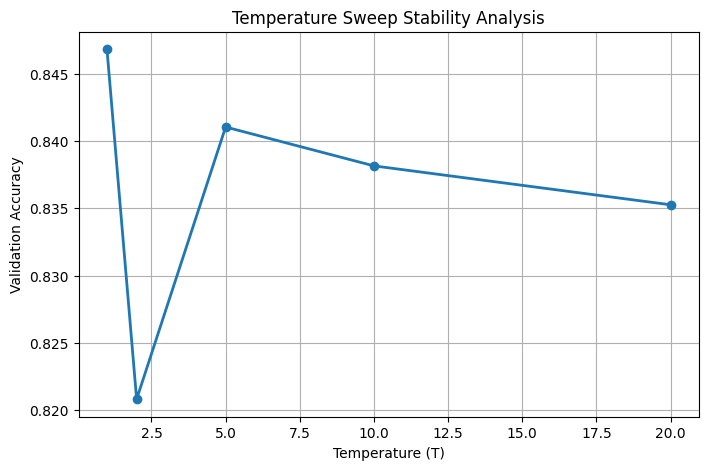

In [ ]:
# ============================================================
# 7. FINAL RESULTS
# ============================================================

print("\n================================================")
print("TEMPERATURE SWEEP RESULTS")
print("================================================")

for T, acc in zip(
    temperature_values,
    temperature_results
):

    print(
        f"T = {T:<3} | Accuracy = {acc:.4f}"
    )

# ============================================================
# 8. PLOT
# ============================================================

fig = plt.figure(figsize=(8,5))

plt.plot(
    temperature_values,
    temperature_results,
    marker='o',
    linewidth=2
)

plt.xlabel(
    "Temperature (T)"
)

plt.ylabel(
    "Validation Accuracy"
)

plt.title(
    "Temperature Sweep Stability Analysis"
)

plt.grid(True)


In [ ]:
# ============================================================
# 9. SAVE FIGURE
# ============================================================

save_path = "/content/temperature_sweep.png"

fig.savefig(
    save_path,
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("\nSaved:")
print(save_path)



Saved:
/content/temperature_sweep.png


In [ ]:
# ============================================================
# 10. DOWNLOAD
# ============================================================

from google.colab import files

files.download(save_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>